# Feature Engineering

> *"Feature engineering is the process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data."*

## Learning Objectives
- Understand what feature engineering is and why it is critical to ML success
- Know the five sub-problems: **importance**, **extraction**, **selection**, **construction**, **learning**
- Apply concrete techniques: one-hot encoding, datetime decomposition, log transforms, binning
- Use scikit-learn tools for feature importance, selection, and extraction
- Understand where feature engineering fits in the full ML workflow

## What Is Feature Engineering and Why Does It Matter?

A **feature** is any measurable property of the data used as input to a model. Raw data is rarely in the right shape — feature engineering is the craft of transforming it so that models can learn more effectively.

Three compounding benefits:

| Benefit | What it means in practice |
|---|---|
| **Flexibility** | Good features work across many model families — you are less locked to one algorithm |
| **Simplicity** | Better features let you use simpler, more maintainable models |
| **Performance** | Superior features directly raise accuracy on unseen data |

> *"The algorithms we used are very standard for Kagglers. We spent most of our efforts in feature engineering."* — Xavier Conort, DataRobot

## Feature Engineering as a Representation Problem

At its core, feature engineering is a **representation problem**: how do you express raw inputs in a form that an algorithm can understand and exploit?

> *"Much of the success of machine learning is actually success in engineering features that a learner can understand."* — Scott Locklin

The catch: **the best representation is unknowable analytically upfront**. You cannot reason your way to the optimal feature set — it must be discovered empirically through building, evaluating, and iterating.

---

> ### The Central Principle
> **Simple algorithms with well-engineered features outperform complex algorithms with poor features.**
>
> Better features let you use faster, simpler, more interpretable models — and still get better results. This is why competition winners consistently credit feature engineering, not model choice.

---

Feature engineering is also a **craft learned through apprenticeship** — like engineering, programming, or medicine. Methodical procedures exist, but knowing *which* procedure to apply to *which* data requires hands-on practice and studying practitioners who do it well.

In [71]:
from IPython.display import HTML, display

display(HTML("""
<figure style="margin:16px 0">
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 700 160" width="700" height="160"
     font-family="Segoe UI, Arial, sans-serif">
  <defs>
    <marker id="arr" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto">
      <path d="M0,0 L0,6 L9,3 z" fill="#555"/>
    </marker>
  </defs>
  <rect width="700" height="160" fill="#f9f9fb" rx="8"/>
  <text x="350" y="24" text-anchor="middle" font-size="13" font-weight="bold" fill="#1a1a2e">The Three Benefits of Good Feature Engineering</text>
  <rect x="20"  y="44" width="190" height="96" rx="8" fill="#dce9f7" stroke="#2166ac" stroke-width="1.5"/>
  <text x="115" y="72"  text-anchor="middle" font-size="13" font-weight="bold" fill="#2166ac">Flexibility</text>
  <text x="115" y="92"  text-anchor="middle" font-size="10" fill="#333">Features that generalise</text>
  <text x="115" y="108" text-anchor="middle" font-size="10" fill="#333">across model families</text>
  <text x="115" y="128" text-anchor="middle" font-size="10" fill="#555">Less algorithm lock-in</text>
  <rect x="255" y="44" width="190" height="96" rx="8" fill="#e8f5e9" stroke="#3a8c3f" stroke-width="1.5"/>
  <text x="350" y="72"  text-anchor="middle" font-size="13" font-weight="bold" fill="#2e7d32">Simplicity</text>
  <text x="350" y="92"  text-anchor="middle" font-size="10" fill="#333">Better features → simpler</text>
  <text x="350" y="108" text-anchor="middle" font-size="10" fill="#333">models that still win</text>
  <text x="350" y="128" text-anchor="middle" font-size="10" fill="#555">Easier to maintain &amp; explain</text>
  <rect x="490" y="44" width="190" height="96" rx="8" fill="#fde8e8" stroke="#c0392b" stroke-width="1.5"/>
  <text x="585" y="72"  text-anchor="middle" font-size="13" font-weight="bold" fill="#c0392b">Performance</text>
  <text x="585" y="92"  text-anchor="middle" font-size="10" fill="#333">Better accuracy on</text>
  <text x="585" y="108" text-anchor="middle" font-size="10" fill="#333">unseen data</text>
  <text x="585" y="128" text-anchor="middle" font-size="10" fill="#555">The ultimate goal</text>
</svg>
</figure>
"""))

## Where Feature Engineering Fits in the ML Workflow

Feature engineering lives in the **Transform Data** stage, but it is deeply iterative — model evaluation feeds back into feature ideas.

In [72]:
from IPython.display import HTML, display

display(HTML("""
<figure style="margin:16px 0">
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 740 200" width="740" height="200"
     font-family="Segoe UI, Arial, sans-serif">
  <defs>
    <marker id="fw" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto">
      <path d="M0,0 L0,6 L9,3 z" fill="#555"/>
    </marker>
    <marker id="fb" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto">
      <path d="M0,0 L0,6 L9,3 z" fill="#c0392b"/>
    </marker>
  </defs>
  <rect width="740" height="200" fill="#f9f9fb" rx="8"/>
  <text x="370" y="24" text-anchor="middle" font-size="13" font-weight="bold" fill="#1a1a2e">ML Workflow — Feature Engineering lives in Transform</text>

  <rect x="14"  y="44" width="110" height="48" rx="7" fill="#e8ecf5" stroke="#555" stroke-width="1.5"/>
  <text x="69"  y="65" text-anchor="middle" font-size="11" font-weight="bold" fill="#333">Select</text>
  <text x="69"  y="83" text-anchor="middle" font-size="10" fill="#555">Data</text>

  <rect x="154" y="44" width="110" height="48" rx="7" fill="#e8ecf5" stroke="#555" stroke-width="1.5"/>
  <text x="209" y="65" text-anchor="middle" font-size="11" font-weight="bold" fill="#333">Preprocess</text>
  <text x="209" y="83" text-anchor="middle" font-size="10" fill="#555">Data</text>

  <rect x="294" y="36" width="110" height="64" rx="7" fill="#fff3cd" stroke="#e6a817" stroke-width="2"/>
  <text x="349" y="60" text-anchor="middle" font-size="11" font-weight="bold" fill="#856404">Transform</text>
  <text x="349" y="76" text-anchor="middle" font-size="10" fill="#856404">Data</text>
  <text x="349" y="91" text-anchor="middle" font-size="9"  fill="#856404">← Feature Eng.</text>

  <rect x="434" y="44" width="110" height="48" rx="7" fill="#e8ecf5" stroke="#555" stroke-width="1.5"/>
  <text x="489" y="65" text-anchor="middle" font-size="11" font-weight="bold" fill="#333">Model</text>
  <text x="489" y="83" text-anchor="middle" font-size="10" fill="#555">Data</text>

  <rect x="574" y="44" width="152" height="48" rx="7" fill="#e8ecf5" stroke="#555" stroke-width="1.5"/>
  <text x="650" y="65" text-anchor="middle" font-size="11" font-weight="bold" fill="#333">Evaluate</text>
  <text x="650" y="83" text-anchor="middle" font-size="10" fill="#555">&amp; Iterate</text>

  <line x1="126" y1="68" x2="152" y2="68" stroke="#555" stroke-width="1.8" marker-end="url(#fw)"/>
  <line x1="266" y1="68" x2="292" y2="68" stroke="#555" stroke-width="1.8" marker-end="url(#fw)"/>
  <line x1="406" y1="68" x2="432" y2="68" stroke="#555" stroke-width="1.8" marker-end="url(#fw)"/>
  <line x1="546" y1="68" x2="572" y2="68" stroke="#555" stroke-width="1.8" marker-end="url(#fw)"/>

  <path d="M650,94 Q650,160 349,160 Q200,160 200,94" fill="none" stroke="#c0392b" stroke-width="1.6" stroke-dasharray="6,3" marker-end="url(#fb)"/>
  <text x="430" y="175" text-anchor="middle" font-size="10" fill="#c0392b">feedback loop — evaluation drives new feature ideas</text>

  <rect x="14" y="130" width="710" height="52" rx="7" fill="#e8f5e9" stroke="#3a8c3f" stroke-width="1.2"/>
  <text x="370" y="150" text-anchor="middle" font-size="11" font-weight="bold" fill="#2e7d32">Iterative Feature Engineering Cycle</text>
  <text x="370" y="168" text-anchor="middle" font-size="10" fill="#2e7d32">Brainstorm features  →  Devise features  →  Select features  →  Evaluate model  →  (repeat)</text>
</svg>
</figure>
"""))

## The Five Sub-Problems

Feature engineering decomposes into five distinct challenges:

| Sub-Problem | Core question | Typical approach |
|---|---|---|
| **Feature Importance** | Which features are useful at all? | Correlation, model-based scoring |
| **Feature Extraction** | How do I compress high-dimensional data? | PCA, autoencoders, embeddings |
| **Feature Selection** | Which subset gives the best model? | Filter, wrapper, embedded methods |
| **Feature Construction** | Can I create better features manually? | Decompose, aggregate, transform |
| **Feature Learning** | Can the model learn features automatically? | Deep learning, representation learning |

In [73]:
from IPython.display import HTML, display

display(HTML("""
<figure style="margin:16px 0">
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 740 220" width="740" height="220"
     font-family="Segoe UI, Arial, sans-serif">
  <rect width="740" height="220" fill="#f9f9fb" rx="8"/>
  <text x="370" y="24" text-anchor="middle" font-size="13" font-weight="bold" fill="#1a1a2e">Five Sub-Problems of Feature Engineering</text>

  <rect x="14"  y="40" width="130" height="154" rx="8" fill="#dce9f7" stroke="#2166ac" stroke-width="1.5"/>
  <text x="79"  y="64"  text-anchor="middle" font-size="12" font-weight="bold" fill="#2166ac">Importance</text>
  <text x="79"  y="84"  text-anchor="middle" font-size="9"  fill="#333">Which features</text>
  <text x="79"  y="98"  text-anchor="middle" font-size="9"  fill="#333">are useful?</text>
  <text x="79"  y="120" text-anchor="middle" font-size="9"  fill="#555">Correlation</text>
  <text x="79"  y="134" text-anchor="middle" font-size="9"  fill="#555">Random Forest</text>
  <text x="79"  y="148" text-anchor="middle" font-size="9"  fill="#555">importance scores</text>

  <rect x="158" y="40" width="130" height="154" rx="8" fill="#e8f5e9" stroke="#3a8c3f" stroke-width="1.5"/>
  <text x="223" y="64"  text-anchor="middle" font-size="12" font-weight="bold" fill="#2e7d32">Extraction</text>
  <text x="223" y="84"  text-anchor="middle" font-size="9"  fill="#333">Compress high-dim</text>
  <text x="223" y="98"  text-anchor="middle" font-size="9"  fill="#333">data automatically</text>
  <text x="223" y="120" text-anchor="middle" font-size="9"  fill="#555">PCA / NMF</text>
  <text x="223" y="134" text-anchor="middle" font-size="9"  fill="#555">images, audio</text>
  <text x="223" y="148" text-anchor="middle" font-size="9"  fill="#555">text embeddings</text>

  <rect x="302" y="40" width="130" height="154" rx="8" fill="#fff3cd" stroke="#e6a817" stroke-width="1.5"/>
  <text x="367" y="64"  text-anchor="middle" font-size="12" font-weight="bold" fill="#856404">Selection</text>
  <text x="367" y="84"  text-anchor="middle" font-size="9"  fill="#333">Choose best subset</text>
  <text x="367" y="98"  text-anchor="middle" font-size="9"  fill="#333">of existing features</text>
  <text x="367" y="120" text-anchor="middle" font-size="9"  fill="#555">Filter (F-score)</text>
  <text x="367" y="134" text-anchor="middle" font-size="9"  fill="#555">Wrapper (RFE)</text>
  <text x="367" y="148" text-anchor="middle" font-size="9"  fill="#555">Embedded (Lasso)</text>

  <rect x="446" y="40" width="130" height="154" rx="8" fill="#fde8e8" stroke="#c0392b" stroke-width="1.5"/>
  <text x="511" y="64"  text-anchor="middle" font-size="12" font-weight="bold" fill="#c0392b">Construction</text>
  <text x="511" y="84"  text-anchor="middle" font-size="9"  fill="#333">Manually create</text>
  <text x="511" y="98"  text-anchor="middle" font-size="9"  fill="#333">new features</text>
  <text x="511" y="120" text-anchor="middle" font-size="9"  fill="#555">Decompose dates</text>
  <text x="511" y="134" text-anchor="middle" font-size="9"  fill="#555">One-hot encoding</text>
  <text x="511" y="148" text-anchor="middle" font-size="9"  fill="#555">Log / bin / ratio</text>

  <rect x="590" y="40" width="136" height="154" rx="8" fill="#ede7f6" stroke="#7b2d8b" stroke-width="1.5"/>
  <text x="658" y="64"  text-anchor="middle" font-size="12" font-weight="bold" fill="#7b2d8b">Learning</text>
  <text x="658" y="84"  text-anchor="middle" font-size="9"  fill="#333">Model learns its</text>
  <text x="658" y="98"  text-anchor="middle" font-size="9"  fill="#333">own features</text>
  <text x="658" y="120" text-anchor="middle" font-size="9"  fill="#555">Autoencoders</text>
  <text x="658" y="134" text-anchor="middle" font-size="9"  fill="#555">CNNs / RNNs</text>
  <text x="658" y="148" text-anchor="middle" font-size="9"  fill="#555">Word2Vec / BERT</text>

  <text x="370" y="210" text-anchor="middle" font-size="9" fill="#888">Construction is considered the most artful — requires domain knowledge and empirical experimentation</text>
</svg>
</figure>
"""))

## 1. Feature Importance

Before engineering, it is useful to score existing features — identifying which carry signal and which are noise.

### All Methods at a Glance

| Method | How it works | When to use |
|---|---|---|
| **RF `feature_importances_`** | Mean decrease in impurity across all trees | Quick baseline with a tree model; fast, no extra cost |
| **GBM `feature_importances_`** | Gain-based importance from boosting iterations | When GBM is your production model; often more stable than RF MDI |
| **Permutation Importance** | Shuffle each feature, measure performance drop | Model-agnostic; accounts for interactions; use when you want to validate RF/GBM scores |
| **SHAP Values** | Game-theory allocation of prediction credit | Need both local (per-row) and global explanations; the most principled method, but slower |
| **Mutual Information** | Measures statistical dependency (any relationship) | Filter-stage ranking before training; works for non-linear relationships; fast |
| **Pearson / Spearman Correlation** | Linear / monotonic relationship with target | Numeric targets; quick sanity check; misses non-linear structure |
| **Chi-squared test** | Association between categorical feature and class label | Classification with categorical or count features; use with `SelectKBest(chi2)` |
| **LASSO coefficients** | L1 penalty drives irrelevant coefficients to zero | When linear model is appropriate; gives importances and selection simultaneously |
| **Variance Inflation Factor (VIF)** | Measures multicollinearity between features | Detect redundant correlated features before linear models |

### Rule of Thumb
- Use **Mutual Information** or **Correlation** as a cheap first pass (no model needed)  
- Use **RF / GBM importances** once you have a baseline model  
- Use **Permutation Importance** to double-check tree importances (tree MDI can over-rank high-cardinality features)  
- Use **SHAP** when you need to explain predictions to stakeholders  

A **Random Forest** exposes `feature_importances_` based on mean decrease in impurity (MDI) — shown below.

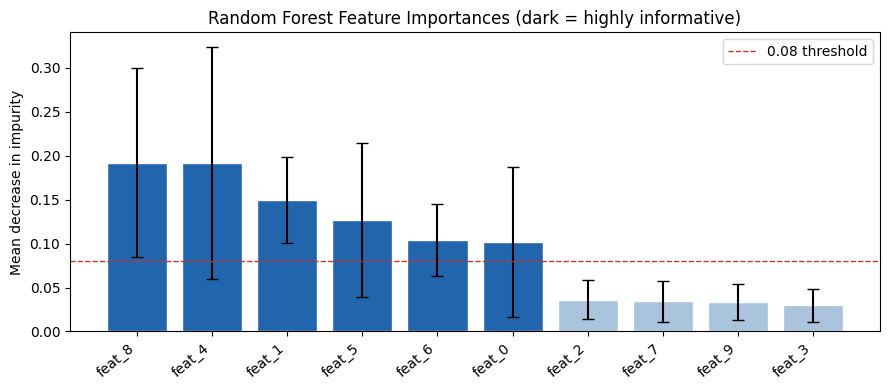

Top 4 features: ['feat_8', 'feat_4', 'feat_1', 'feat_5']


In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
X, y = make_classification(
    n_samples=600, n_features=10, n_informative=4,
    n_redundant=2, random_state=42
)
feature_names = [f'feat_{i}' for i in range(10)]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
std         = np.std([t.feature_importances_ for t in rf.estimators_], axis=0)
order       = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2166ac' if importances[i] > 0.08 else '#aac4de' for i in order]
ax.bar(range(10), importances[order], yerr=std[order],
       color=colors, capsize=4, edgecolor='white')
ax.set_xticks(range(10))
ax.set_xticklabels([feature_names[i] for i in order], rotation=40, ha='right')
ax.set_title('Random Forest Feature Importances (dark = highly informative)', fontsize=12)
ax.set_ylabel('Mean decrease in impurity')
ax.axhline(0.08, color='#c0392b', linestyle='--', linewidth=1, label='0.08 threshold')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 4 features:", [feature_names[order[i]] for i in range(4)])

### Gradient Boosted Machine (GBM) Feature Importance

Besides Random Forest, **Gradient Boosted Machines** also expose internal importance scores — based on how much each feature reduces loss across all boosting iterations. The two methods often agree but can diverge, especially when features are correlated. Using both gives a more robust signal.

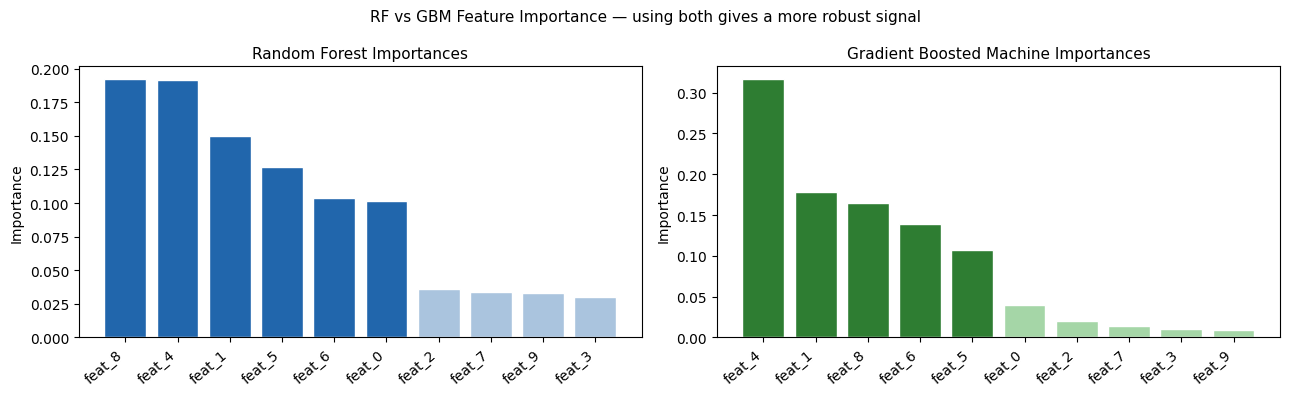

Feature       RF rank   GBM rank   Agree?
------------------------------------------
feat_0              6          6      yes
feat_1              3          2      yes
feat_2              7          7      yes
feat_3             10          9      yes
feat_4              2          1      yes
feat_5              4          5      yes
feat_6              5          4      yes
feat_7              8          8      yes
feat_8              1          3      yes
feat_9              9         10      yes


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

np.random.seed(42)
X, y = make_classification(
    n_samples=600, n_features=10, n_informative=4,
    n_redundant=2, random_state=42
)
feature_names = [f'feat_{i}' for i in range(10)]

rf  = RandomForestClassifier(n_estimators=200, random_state=42).fit(X, y)
gbm = GradientBoostingClassifier(n_estimators=200, random_state=42).fit(X, y)

rf_order  = np.argsort(rf.feature_importances_)[::-1]
gbm_order = np.argsort(gbm.feature_importances_)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rf_colors = ['#2166ac' if rf.feature_importances_[i] > 0.08 else '#aac4de' for i in rf_order]
axes[0].bar(range(10), rf.feature_importances_[rf_order], color=rf_colors, edgecolor='white')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels([feature_names[i] for i in rf_order], rotation=40, ha='right')
axes[0].set_title('Random Forest Importances', fontsize=11)
axes[0].set_ylabel('Importance')

gbm_colors = ['#2e7d32' if gbm.feature_importances_[i] > 0.08 else '#a5d6a7' for i in gbm_order]
axes[1].bar(range(10), gbm.feature_importances_[gbm_order], color=gbm_colors, edgecolor='white')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([feature_names[i] for i in gbm_order], rotation=40, ha='right')
axes[1].set_title('Gradient Boosted Machine Importances', fontsize=11)
axes[1].set_ylabel('Importance')

plt.suptitle('RF vs GBM Feature Importance — using both gives a more robust signal', fontsize=11)
plt.tight_layout()
plt.show()

# rank agreement
rf_rank  = {feature_names[i]: r + 1 for r, i in enumerate(rf_order)}
gbm_rank = {feature_names[i]: r + 1 for r, i in enumerate(gbm_order)}
print(f"{'Feature':<12} {'RF rank':>8} {'GBM rank':>10} {'Agree?':>8}")
print('-' * 42)
for f in feature_names:
    agree = 'yes' if abs(rf_rank[f] - gbm_rank[f]) <= 2 else 'DIVERGE'
    print(f"{f:<12} {rf_rank[f]:>8} {gbm_rank[f]:>10} {agree:>8}")

## 1b. Correlation & Covariance Matrix

Before diving into model-based importance, two classical tools give you a quick, model-free picture of how features relate to each other and to the target.

### Correlation Matrix

The **correlation matrix** shows pairwise **Pearson r** values between all features (and the target). It answers:
- Which features are **redundant** (high feature-feature correlation)?
- Which features have a **linear relationship with the target**?

A pair with |r| > 0.8–0.9 is nearly redundant — keeping both adds noise but little new signal.

### Covariance Matrix

The **covariance matrix** Σ stores the variance of each feature on its diagonal and the covariance (un-normalised correlation) off-diagonal.  
Correlation is just the normalised version: r = Cov(X, Y) / (σ_X × σ_Y).

**Why it matters beyond EDA:** PCA is an eigendecomposition of the covariance matrix.  
The eigenvectors are the principal component directions; the eigenvalues tell you how much variance each component captures.  
So studying the covariance matrix directly tells you *why* PCA produces the components it does.

### Methods at a Glance

| Method | What it measures | When to use |
|---|---|---|
| **Pearson correlation matrix** | Linear relationships (−1 to +1) | Standard first look; assumes roughly numeric, not too skewed |
| **Spearman rank correlation** | Monotonic relationships (rank-based) | Non-normal distributions, ordinal features, outlier-heavy data |
| **Kendall's Tau** | Concordance of rank pairs | Small samples; more robust to outliers than Spearman |
| **Covariance matrix** | Scale-dependent joint spread | Input to PCA and Mahalanobis distance; raw magnitude matters |
| **Partial correlation** | Correlation with all other features partialled out | Detect direct relationships when confounders are present |
| **VIF (Variance Inflation Factor)** | How much a feature's variance is inflated by collinearity | Diagnosing multicollinearity before fitting linear/logistic regression |

### Rule of Thumb
- Plot the **Pearson heatmap** as a standard EDA step — flag any |r| > 0.85 pair for potential removal  
- Use **Spearman** when your data is skewed or ordinal  
- Check **VIF > 5–10** before linear models — high VIF means an unstable coefficient  
- Understand the **covariance matrix** conceptually when studying PCA — the two are inseparable

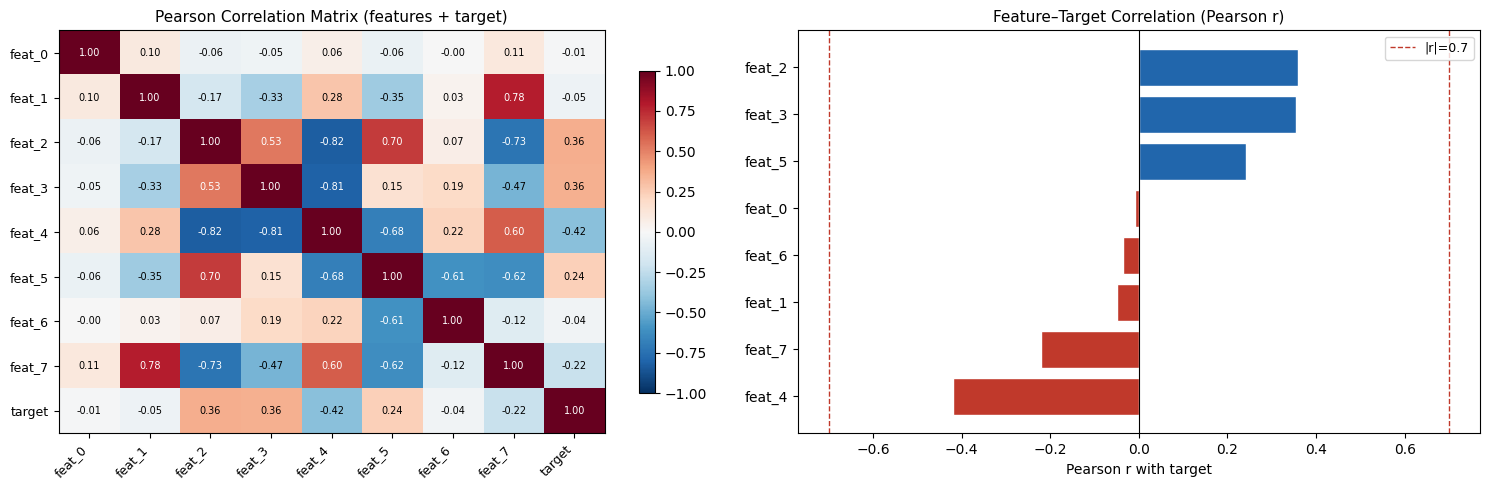

Strongly correlated feature pairs (|r| > 0.7):
  feat_1 ↔ feat_7: r = 0.783  ← consider dropping one
  feat_2 ↔ feat_4: r = -0.821  ← consider dropping one
  feat_2 ↔ feat_7: r = -0.729  ← consider dropping one
  feat_3 ↔ feat_4: r = -0.807  ← consider dropping one


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

np.random.seed(42)
X, y = make_classification(
    n_samples=600, n_features=8, n_informative=4,
    n_redundant=3, random_state=42
)
feature_names = [f'feat_{i}' for i in range(8)]

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pearson correlation matrix (features + target)
corr = df.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# heatmap
im = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(corr)))
axes[0].set_yticks(range(len(corr)))
axes[0].set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(corr.columns, fontsize=9)
axes[0].set_title('Pearson Correlation Matrix (features + target)', fontsize=11)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# annotate cells
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=7, color=color)

# highlight strongly correlated feature pairs (|r| > 0.7, excluding diagonal and target)
threshold = 0.7
pairs = []
feat_corr = corr.loc[feature_names, feature_names]
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        r = feat_corr.iloc[i, j]
        if abs(r) > threshold:
            pairs.append((feature_names[i], feature_names[j], r))

# bar chart of feature-target correlations
feat_target = corr['target'].drop('target').sort_values()
colors = ['#c0392b' if v < 0 else '#2166ac' for v in feat_target]
axes[1].barh(feat_target.index, feat_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline( threshold, color='#c0392b', linestyle='--', linewidth=1, label=f'|r|={threshold}')
axes[1].axvline(-threshold, color='#c0392b', linestyle='--', linewidth=1)
axes[1].set_title('Feature–Target Correlation (Pearson r)', fontsize=11)
axes[1].set_xlabel('Pearson r with target')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Strongly correlated feature pairs (|r| > {threshold}):")
if pairs:
    for f1, f2, r in pairs:
        print(f"  {f1} ↔ {f2}: r = {r:.3f}  ← consider dropping one")
else:
    print("  None found above threshold")

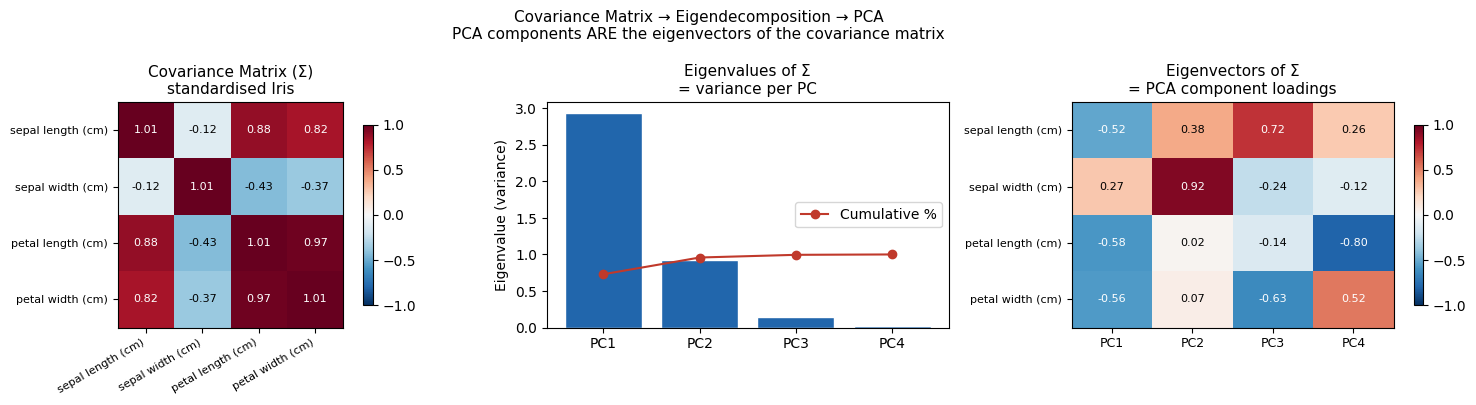

Eigenvalue (Σ)      vs  PCA explained variance
------------------------------------------------
  PC1: eigenvalue=2.938 (73.0%)  |  PCA var_ratio=73.0%
  PC2: eigenvalue=0.920 (22.9%)  |  PCA var_ratio=22.9%
  PC3: eigenvalue=0.148 (3.7%)  |  PCA var_ratio=3.7%
  PC4: eigenvalue=0.021 (0.5%)  |  PCA var_ratio=0.5%


In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris   = load_iris()
X      = StandardScaler().fit_transform(iris.data)
labels = iris.feature_names

# covariance matrix (on standardised data = correlation matrix)
cov = np.cov(X.T)

# eigendecomposition — this is exactly what PCA computes
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# sort descending (eigh returns ascending)
idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# PCA for verification
pca     = PCA().fit(X)
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# covariance matrix heatmap
im = axes[0].imshow(cov, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title('Covariance Matrix (Σ)\nstandardised Iris', fontsize=11)
plt.colorbar(im, ax=axes[0], shrink=0.8)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{cov[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if abs(cov[i,j]) > 0.5 else 'black')

# eigenvalues = variance captured by each PC
axes[1].bar(range(1, 5), eigenvalues, color='#2166ac', edgecolor='white')
axes[1].plot(range(1, 5), np.cumsum(eigenvalues) / eigenvalues.sum(),
             'o-', color='#c0392b', label='Cumulative %')
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels([f'PC{i}' for i in range(1, 5)])
axes[1].set_title('Eigenvalues of Σ\n= variance per PC', fontsize=11)
axes[1].set_ylabel('Eigenvalue (variance)')
axes[1].legend(loc='center right')

# eigenvectors = PC loadings — how original features map to each PC
im2 = axes[2].imshow(eigenvectors, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))
axes[2].set_xticklabels([f'PC{i+1}' for i in range(4)], fontsize=9)
axes[2].set_yticklabels(labels, fontsize=8)
axes[2].set_title('Eigenvectors of Σ\n= PCA component loadings', fontsize=11)
plt.colorbar(im2, ax=axes[2], shrink=0.8)
for i in range(4):
    for j in range(4):
        axes[2].text(j, i, f'{eigenvectors[i,j]:.2f}',
                     ha='center', va='center', fontsize=8,
                     color='white' if abs(eigenvectors[i,j]) > 0.5 else 'black')

plt.suptitle('Covariance Matrix → Eigendecomposition → PCA\n'
             'PCA components ARE the eigenvectors of the covariance matrix',
             fontsize=11)
plt.tight_layout()
plt.show()

print("Eigenvalue (Σ)      vs  PCA explained variance")
print("-" * 48)
for i in range(4):
    share_eig = eigenvalues[i] / eigenvalues.sum()
    print(f"  PC{i+1}: eigenvalue={eigenvalues[i]:.3f} "
          f"({share_eig:.1%})  |  PCA var_ratio={var_exp[i]:.1%}")

## 2. Feature Extraction

When data is inherently high-dimensional (images, audio, text), feature extraction **automatically reduces** dimensionality into a compact set of derived features.

### All Methods at a Glance

| Method | How it works | When to use |
|---|---|---|
| **PCA** | Linear projection onto directions of max variance | General-purpose numeric data; fast; interpretable as variance retained |
| **NMF** | Factorizes into non-negative components | Data with natural non-negativity (counts, images, spectra) — parts-based decomposition |
| **ICA** | Finds statistically independent components | Signal separation: audio (blind source separation), EEG/fMRI |
| **TruncatedSVD (LSA)** | SVD on sparse matrices without centering | Text / TF-IDF data; works directly on sparse matrices (PCA requires dense) |
| **t-SNE** | Non-linear perplexity-based embedding | 2D/3D **visualization only** — not suitable as model input (non-deterministic, no transform) |
| **UMAP** | Non-linear manifold learning | Visualization or pre-processing; faster + better global structure than t-SNE; can transform new data |
| **Autoencoders** | Neural encoder-decoder, non-linear bottleneck | Large data, complex non-linear structure; when PCA variance retention is too low |
| **Word2Vec / BERT embeddings** | Distributional / attention-based text representations | NLP — text → dense numeric vectors; domain-specific pre-trained models exist |

### Rule of Thumb
- Start with **PCA** — fast, explainable, often good enough  
- Use **TruncatedSVD** when your matrix is sparse (text)  
- Use **NMF** when non-negativity has semantic meaning (topic proportions, pixel intensities)  
- Use **t-SNE / UMAP** only for visualization — never feed their output into a model for evaluation  
- Use **Autoencoders** when PCA's retained variance is too low and you have enough data to train a network  

**PCA** (Principal Component Analysis) projects data onto orthogonal directions of maximum variance — turning $n$ correlated dimensions into $k$ independent components. Shown below.

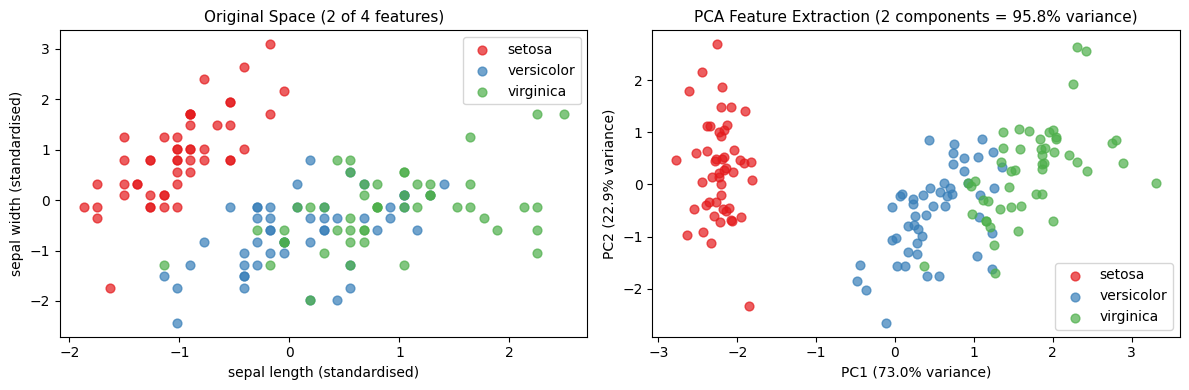

Original dimensions : 4
Extracted dimensions: 2
Variance retained   : 95.81%


In [78]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris    = load_iris()
X_iris  = StandardScaler().fit_transform(iris.data)
y_iris  = iris.target
labels  = iris.target_names

pca     = PCA(n_components=2)
X_pca   = pca.fit_transform(X_iris)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e41a1c', '#377eb8', '#4daf4a']

# original: plot first two of four features
for cls in range(3):
    mask = y_iris == cls
    axes[0].scatter(X_iris[mask, 0], X_iris[mask, 1],
                    color=colors[cls], label=labels[cls], alpha=0.7, s=40)
axes[0].set_title('Original Space (2 of 4 features)', fontsize=11)
axes[0].set_xlabel('sepal length (standardised)')
axes[0].set_ylabel('sepal width (standardised)')
axes[0].legend()

# extracted: PCA components
for cls in range(3):
    mask = y_iris == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=colors[cls], label=labels[cls], alpha=0.7, s=40)
ev = pca.explained_variance_ratio_
axes[1].set_title(f'PCA Feature Extraction (2 components = {sum(ev):.1%} variance)', fontsize=11)
axes[1].set_xlabel(f'PC1 ({ev[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({ev[1]:.1%} variance)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Original dimensions : {iris.data.shape[1]}")
print(f"Extracted dimensions: {X_pca.shape[1]}")
print(f"Variance retained   : {sum(ev):.2%}")

## 3. Feature Selection

Feature selection removes **irrelevant or redundant** attributes from the existing feature set — keeping only what is most predictive.

### All Methods at a Glance

**Filter methods** — score each feature independently; no model needed; fast

| Method | How it works | When to use |
|---|---|---|
| **F-statistic (`f_classif` / `f_regression`)** | ANOVA F-test between feature and target | Numeric features + linear relationship assumption; fast first-pass |
| **Mutual Information** | Non-parametric dependency (any shape) | When linear F-test is too restrictive; handles non-linear relationships |
| **Chi-squared** | Association between counts/frequencies and class | Categorical or non-negative integer features for classification |
| **Variance Threshold** | Remove near-constant features | First clean-up step; remove features that carry no information at all |
| **Spearman Correlation** | Monotonic relationship with target | Ordinal features or non-normal distributions |

**Wrapper methods** — search feature subsets by training and evaluating a full model; more accurate but expensive

| Method | How it works | When to use |
|---|---|---|
| **RFE** | Iteratively remove least important features | When you have a preferred model and feature count budget |
| **Sequential Forward Selection** | Greedily add best feature one-by-one | Small feature sets where exhaustive search is feasible |
| **Sequential Backward Selection** | Start with all, greedily remove worst | Same; backward often finds better subsets than forward for correlated data |
| **Boruta** | Random Forest shadow-feature comparison | When you want a statistically rigorous all-relevant feature set |

**Embedded methods** — selection happens during training; no separate step needed

| Method | How it works | When to use |
|---|---|---|
| **LASSO (L1)** | Drives irrelevant coefficients to zero | Linear models; when you expect sparse signal |
| **ElasticNet (L1+L2)** | LASSO + Ridge combined | Correlated features that LASSO would arbitrarily pick one from |
| **Tree importance threshold** | Zero-out features below importance cutoff | When your model is already tree-based; no extra training cost |
| **`SelectFromModel`** | Wrapper around any model with `coef_` or `feature_importances_` | One-step embedded selection for any estimator |

### Rule of Thumb
- **Variance Threshold** first — free noise removal  
- **Mutual Information** next — fast, non-linear, no model needed  
- **RFE** when you want wrapper-level accuracy with a known model  
- **LASSO** when a linear model is appropriate — selection and fitting in one step  
- Avoid filter methods alone for final selection — they ignore feature interactions

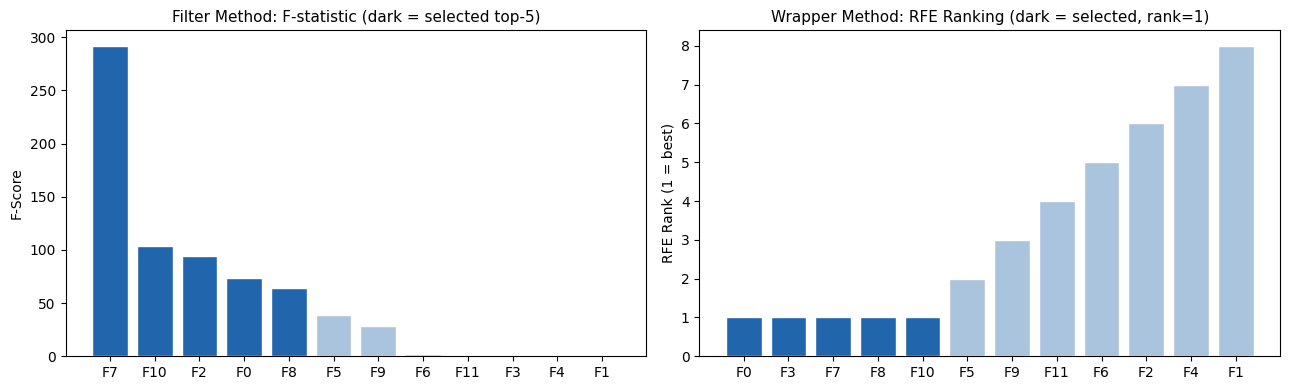

Filter selected : ['F0', 'F2', 'F7', 'F8', 'F10']
RFE selected    : ['F0', 'F3', 'F7', 'F8', 'F10']
Agreement       : ['F0', 'F10', 'F7', 'F8']


In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=600, n_features=12, n_informative=5,
    n_redundant=3, random_state=42
)
names = [f'F{i}' for i in range(12)]
X_sc  = StandardScaler().fit_transform(X)

# Filter: univariate F-statistic
filter_sel = SelectKBest(f_classif, k=5).fit(X_sc, y)

# Wrapper: Recursive Feature Elimination
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=5).fit(X_sc, y)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# filter plot
scores = filter_sel.scores_
order  = np.argsort(scores)[::-1]
sel    = filter_sel.get_support()
colors = ['#2166ac' if sel[i] else '#aac4de' for i in order]
axes[0].bar([names[i] for i in order], scores[order], color=colors, edgecolor='white')
axes[0].set_title('Filter Method: F-statistic (dark = selected top-5)', fontsize=11)
axes[0].set_ylabel('F-Score')

# RFE ranking plot
rfe_order = np.argsort(rfe.ranking_)
rfe_colors = ['#2166ac' if rfe.support_[i] else '#aac4de' for i in rfe_order]
axes[1].bar([names[i] for i in rfe_order], rfe.ranking_[rfe_order],
            color=rfe_colors, edgecolor='white')
axes[1].set_title('Wrapper Method: RFE Ranking (dark = selected, rank=1)', fontsize=11)
axes[1].set_ylabel('RFE Rank (1 = best)')

plt.tight_layout()
plt.show()

filter_selected = [names[i] for i in range(12) if sel[i]]
rfe_selected    = [names[i] for i in range(12) if rfe.support_[i]]
print(f"Filter selected : {filter_selected}")
print(f"RFE selected    : {rfe_selected}")
print(f"Agreement       : {sorted(set(filter_selected) & set(rfe_selected))}")

### Embedded Method: LASSO

**Embedded methods** perform selection *during* training — no separate step needed.

**LASSO (Least Absolute Shrinkage and Selection Operator)** adds an L1 penalty to the loss function:

$$\text{Loss} = \text{RSS} + \lambda \sum_{j=1}^{p} |\beta_j|$$

The L1 penalty drives irrelevant feature coefficients **exactly to zero**, effectively removing those features from the model. This is a key contrast with Ridge (L2), which shrinks coefficients toward zero but never reaches exactly zero.

| Method | Penalty | Zeroes coefficients? | Use when |
|---|---|---|---|
| LASSO | L1 — sum of \|coeff\| | Yes — sparse model | Many features are irrelevant |
| Ridge | L2 — sum of coeff² | No — all features kept | All features contribute a little |
| Elastic Net | L1 + L2 | Yes (via L1 component) | High correlation among features |

`LassoCV` automatically selects the best regularization strength α via cross-validation.

Best alpha (regularization strength): 1.0571
Features selected (non-zero coeff)  : 9 of 15

Selected : ['F0', 'F2', 'F3', 'F4', 'F5', 'F8', 'F9', 'F10', 'F14']
Zeroed   : ['F1', 'F6', 'F7', 'F11', 'F12', 'F13']


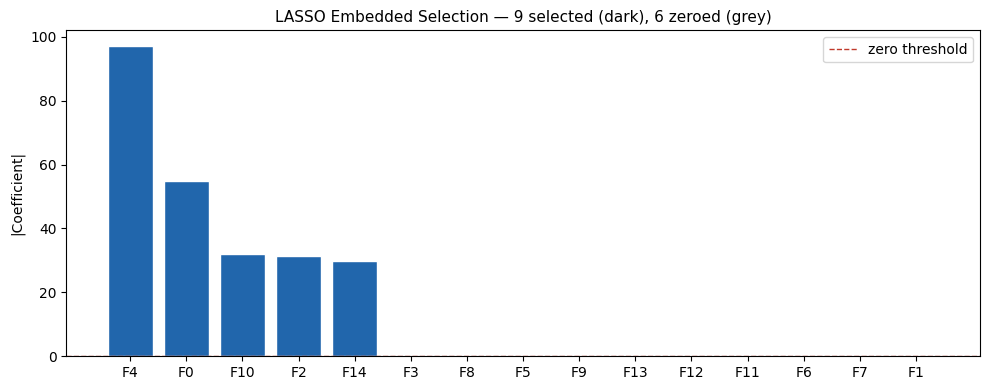

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X, y, true_coef = make_regression(
    n_samples=300, n_features=15, n_informative=5,
    noise=20, coef=True, random_state=42
)
feature_names = [f'F{i}' for i in range(15)]
X_sc = StandardScaler().fit_transform(X)

# LassoCV selects alpha via cross-validation
lasso = LassoCV(cv=5, random_state=42, max_iter=5000).fit(X_sc, y)

coef     = lasso.coef_
selected = np.abs(coef) > 1e-3

print(f"Best alpha (regularization strength): {lasso.alpha_:.4f}")
print(f"Features selected (non-zero coeff)  : {selected.sum()} of {len(coef)}")
print()

selected_names = [feature_names[i] for i in range(15) if selected[i]]
zeroed_names   = [feature_names[i] for i in range(15) if not selected[i]]
print(f"Selected : {selected_names}")
print(f"Zeroed   : {zeroed_names}")

order  = np.argsort(np.abs(coef))[::-1]
colors = ['#2166ac' if selected[i] else '#dddddd' for i in order]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([feature_names[i] for i in order], np.abs(coef[order]),
       color=colors, edgecolor='white')
ax.axhline(1e-3, color='#c0392b', linestyle='--', linewidth=1, label='zero threshold')
ax.set_title(
    f'LASSO Embedded Selection — {selected.sum()} selected (dark), '
    f'{(~selected).sum()} zeroed (grey)',
    fontsize=11
)
ax.set_ylabel('|Coefficient|')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Feature Construction

Feature construction is the most **artful** sub-problem — manually creating new features from raw data using domain knowledge.

### 4a. Decomposing Categorical Attributes

Convert categorical variables into numeric indicators a model can use.

### Encoding Methods at a Glance

| Method | How it works | When to use |
|---|---|---|
| **One-hot encoding** | One binary column per category | Low-to-medium cardinality (< ~20 categories); when categories have no order |
| **Label / ordinal encoding** | Integer per category (0, 1, 2…) | **Only** when categories have a true natural order (e.g., small/medium/large) |
| **Target encoding (mean encoding)** | Replace category with mean of target | High cardinality (cities, product IDs); must use cross-fold encoding to prevent leakage |
| **Binary encoding** | Category → binary bits (log₂ cols) | Medium cardinality; compromise between one-hot column explosion and label encoding |
| **Hashing trick** | Hash category into fixed-size vector | Very high or open-ended cardinality; online learning; accepts unseen categories |
| **Frequency / count encoding** | Replace category with its count in training set | High cardinality; gives signal without target leakage risk |
| **Embeddings (learned)** | Neural lookup table — dense vector per category | NLP or when categories have rich semantic relationships; requires enough data to train |

### Rule of Thumb
- Default to **one-hot** for < 20 categories  
- Use **target encoding** for high cardinality — but always compute per fold to avoid leakage  
- Use **frequency encoding** as a safe, leakage-free alternative to target encoding  
- Never use label encoding on nominal (unordered) categories — models will infer false ordinal relationships  

One-hot encoding creates a binary column per category; binary flags (`is_red`, `has_color`) capture specific properties.

Before encoding:
 item color  price
Shirt   Red     25
Pants  Blue     45
  Hat   Red     15
Shirt Green     30
Shoes  Blue     60
  Hat Green     18

After one-hot encoding:
 item  price  color_Blue  color_Green  color_Red  is_red
Shirt     25           0            0          1       1
Pants     45           1            0          0       0
  Hat     15           0            0          1       1
Shirt     30           0            1          0       0
Shoes     60           1            0          0       0
  Hat     18           0            1          0       0


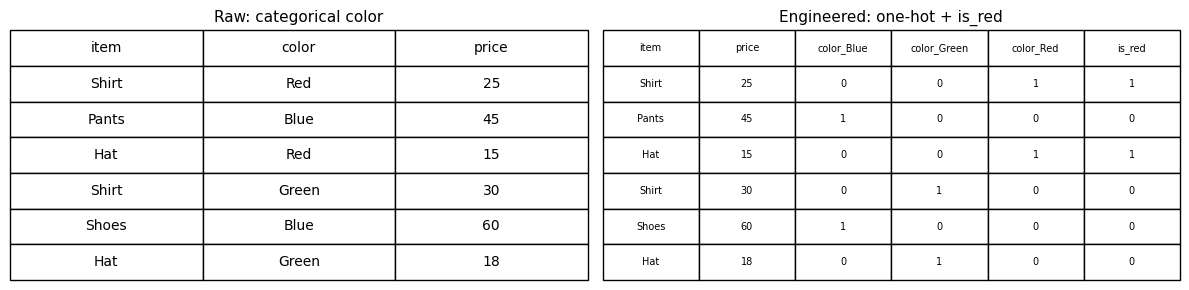

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'item' : ['Shirt', 'Pants', 'Hat', 'Shirt', 'Shoes', 'Hat'],
    'color': ['Red', 'Blue', 'Red', 'Green', 'Blue', 'Green'],
    'price': [25, 45, 15, 30, 60, 18]
})

# one-hot encode the color column
df_encoded = pd.get_dummies(df, columns=['color'], prefix='color', dtype=int)

# binary feature: is the item red?
df_encoded['is_red'] = df['color'].eq('Red').astype(int)

print("Before encoding:")
print(df.to_string(index=False))
print("\nAfter one-hot encoding:")
print(df_encoded.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
axes[0].axis('off')
axes[0].set_title('Raw: categorical color', fontsize=11)

axes[1].table(
    cellText=df_encoded.values,
    colLabels=df_encoded.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
axes[1].axis('off')
axes[1].set_title('Engineered: one-hot + is_red', fontsize=11)

plt.tight_layout()
plt.show()

### Handling Unknown / Missing Categories

A practical extension: when a categorical contains **null or unknown values**, encode them explicitly rather than letting them silently become zeros. Two common patterns:

- `Has_Color` — binary flag: does this row have a known value at all?
- `Is_Unknown` — one-hot column for the unknown state, so the model can learn from absence separately

This is the article's `Item_Color` example: Red, Blue, **Unknown**.

  item item_color  has_color  color_Blue  color_Red  color_Unknown
 Shirt        Red          1           0          1              0
 Pants       Blue          1           1          0              0
   Hat        Red          1           0          1              0
Jacket       None          0           0          0              1
 Shoes       Blue          1           1          0              0
  Belt       None          0           0          0              1
 Scarf        Red          1           0          1              0



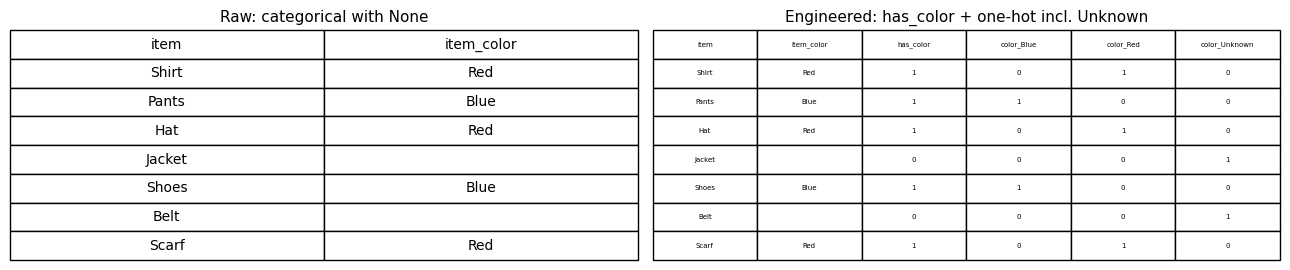

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'item'      : ['Shirt', 'Pants', 'Hat', 'Jacket', 'Shoes', 'Belt', 'Scarf'],
    'item_color': ['Red',   'Blue',  'Red', None,     'Blue',  None,   'Red'],
})

# has_color: 1 = known color, 0 = unknown
df['has_color'] = df['item_color'].notna().astype(int)

# fill None → 'Unknown' so it becomes an explicit one-hot column
df['item_color_filled'] = df['item_color'].fillna('Unknown')
ohe = pd.get_dummies(df['item_color_filled'], prefix='color', dtype=int)
result = pd.concat([df[['item', 'item_color', 'has_color']], ohe], axis=1)

print(result.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 2.8))

axes[0].table(
    cellText=df[['item', 'item_color']].values,
    colLabels=['item', 'item_color'],
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
axes[0].axis('off')
axes[0].set_title('Raw: categorical with None', fontsize=11)

axes[1].table(
    cellText=result.values,
    colLabels=result.columns.tolist(),
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
axes[1].axis('off')
axes[1].set_title('Engineered: has_color + one-hot incl. Unknown', fontsize=11)

plt.tight_layout()
plt.show()

### 4b. Decomposing Date-Time

A raw timestamp is opaque to most models. Decomposing it into structured components exposes the temporal patterns that drive behaviour.

### Datetime Encoding Methods at a Glance

| Method | How it works | When to use |
|---|---|---|
| **Component extraction** | Pull out hour, day, month, year as integers | General-purpose first step; fast and interpretable |
| **Binary flags** | `is_weekend`, `is_holiday`, `is_business_hours` | When a yes/no boundary drives the target (e.g., retail traffic) |
| **Part-of-day binning** | `night / morning / afternoon / evening` | When granular hour is noisy but general period is signal |
| **Cyclic encoding (sin / cos)** | `sin(2π × hour/24)`, `cos(2π × hour/24)` | When cyclical proximity matters: hour 23 and hour 0 should be close — integer encoding breaks this |
| **Time since reference event** | Days since first purchase, days since last activity | When **recency** matters more than the absolute date |
| **Lag features** | Value of target or feature at t-1, t-7, t-30 | Time-series prediction; requires sorted, contiguous data |
| **Rolling statistics** | Rolling mean/std over a window | Smoothed trend features; common in financial / IoT time series |
| **Business calendar** | `is_quarter_end`, `days_to_holiday` | B2B or financial data where calendar events drive spikes |

### Rule of Thumb
- Always start with **component extraction** (hour, weekday, month)  
- Add **cyclic encoding** (sin/cos) whenever a periodic feature wraps: hours of day, months, days of week  
- Add **time-since** features whenever customer recency is expected to matter  
- Use **lag + rolling** features for actual time-series models (with a time-ordered train/test split to avoid leakage)  

Component decomposition into `hour_of_day`, `day_of_week`, `is_weekend`, `part_of_day` is shown below.

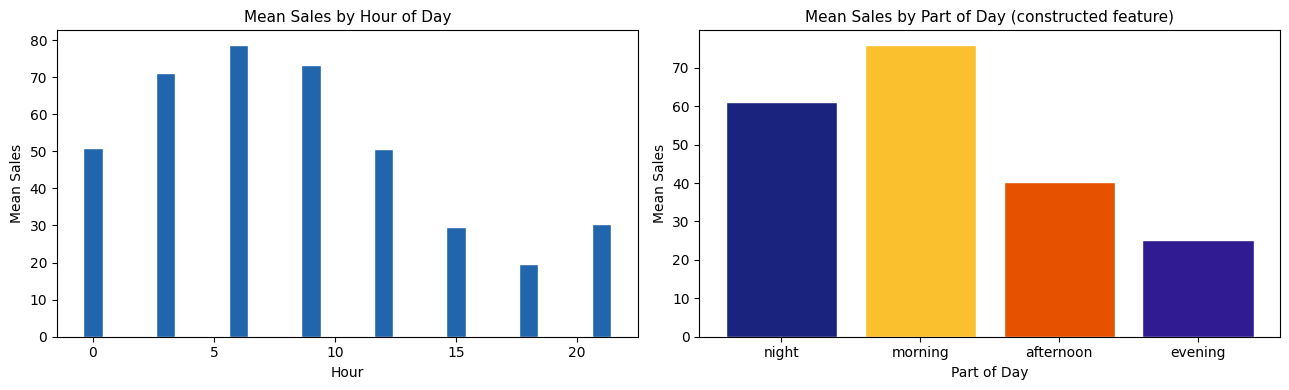

          timestamp  hour  day_of_week  is_weekend part_of_day
2024-01-01 00:00:00     0            0           0       night
2024-01-01 03:00:00     3            0           0       night
2024-01-01 06:00:00     6            0           0     morning
2024-01-01 09:00:00     9            0           0     morning
2024-01-01 12:00:00    12            0           0   afternoon
2024-01-01 15:00:00    15            0           0   afternoon
2024-01-01 18:00:00    18            0           0     evening
2024-01-01 21:00:00    21            0           0     evening


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
dates = pd.date_range('2024-01-01', periods=200, freq='3h')
sales = 50 + 30 * np.sin(2 * np.pi * dates.hour / 24) + np.random.normal(0, 8, 200)

df = pd.DataFrame({'timestamp': dates, 'sales': sales})

# decompose timestamp
df['hour']       = df['timestamp'].dt.hour
df['day_of_week']= df['timestamp'].dt.dayofweek
df['month']      = df['timestamp'].dt.month
df['is_weekend'] = (df['timestamp'].dt.dayofweek >= 5).astype(int)

def part_of_day(h):
    if h < 6:   return 'night'
    if h < 12:  return 'morning'
    if h < 18:  return 'afternoon'
    return 'evening'

df['part_of_day'] = df['hour'].apply(part_of_day)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# sales by hour
hourly = df.groupby('hour')['sales'].mean()
axes[0].bar(hourly.index, hourly.values, color='#2166ac', edgecolor='white')
axes[0].set_title('Mean Sales by Hour of Day', fontsize=11)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Sales')

# sales by part of day
pod_order  = ['night', 'morning', 'afternoon', 'evening']
pod_colors = ['#1a237e', '#fbc02d', '#e65100', '#311b92']
pod_means  = df.groupby('part_of_day')['sales'].mean().reindex(pod_order)
axes[1].bar(pod_order, pod_means.values, color=pod_colors, edgecolor='white')
axes[1].set_title('Mean Sales by Part of Day (constructed feature)', fontsize=11)
axes[1].set_xlabel('Part of Day')
axes[1].set_ylabel('Mean Sales')

plt.tight_layout()
plt.show()

print(df[['timestamp', 'hour', 'day_of_week', 'is_weekend', 'part_of_day']].head(8).to_string(index=False))

### 4c. Reframing Quantities

Raw numeric values often violate model assumptions (e.g., heavy right-skew) or hide useful structure. Reframing transforms the scale or shape of a quantity.

### Numeric Transform Methods at a Glance

| Method | How it works | When to use |
|---|---|---|
| **Log transform** (`log1p`) | Compresses right tail; spreads left | Right-skewed distributions with a natural floor at 0 (income, counts, prices) |
| **Square root** | Milder log-like compression | Count data (Poisson); smaller range; handles zeros without +1 |
| **Box-Cox** | Family of power transforms; finds best λ | Right-skewed **positive** data when you don't know the right transform — CV picks λ |
| **Yeo-Johnson** | Box-Cox extended to zero and negative values | Same as Box-Cox but handles zeros and negatives safely |
| **Quantile transform** | Map to uniform or normal distribution | When you need exact distribution shape; preserves rank, destroys magnitude |
| **Robust scaling** | Scale by median and IQR | Data with outliers; avoids outlier domination unlike standard scaling |
| **Binning / discretization** | Cut continuous into ordered categories | Non-linear relationship suspected; model treats ranges as separate entities |
| **Threshold flags** | Binary: above/below a meaningful cutoff | Domain-knowledge boundaries (e.g., ≥ 4 kg → higher shipping tier) |
| **Ratio / rate** | Divide one quantity by another | When absolute scale is misleading (revenue per customer, rate per 100k population) |
| **Polynomial features** | x², x³, x₁×x₂ interaction terms | Explicit non-linearity for linear models; dangerous with many features (explosion) |

### Rule of Thumb
- **Log transform** is the default for right-skewed positive quantities  
- Use **Yeo-Johnson** (via `PowerTransformer`) when data includes zeros or negatives — it handles everything Box-Cox can't  
- Use **Quantile transform** only when distributional normality matters (e.g., Gaussian process models), not when interpretability is needed  
- **Binning** + **threshold flags** are most useful for tree-agnostic models (linear, kNN, SVM) that cannot learn splits themselves  
- Avoid polynomial features beyond degree 2 — feature explosion makes selection mandatory  

Log transform, binning, and threshold flags are shown below.

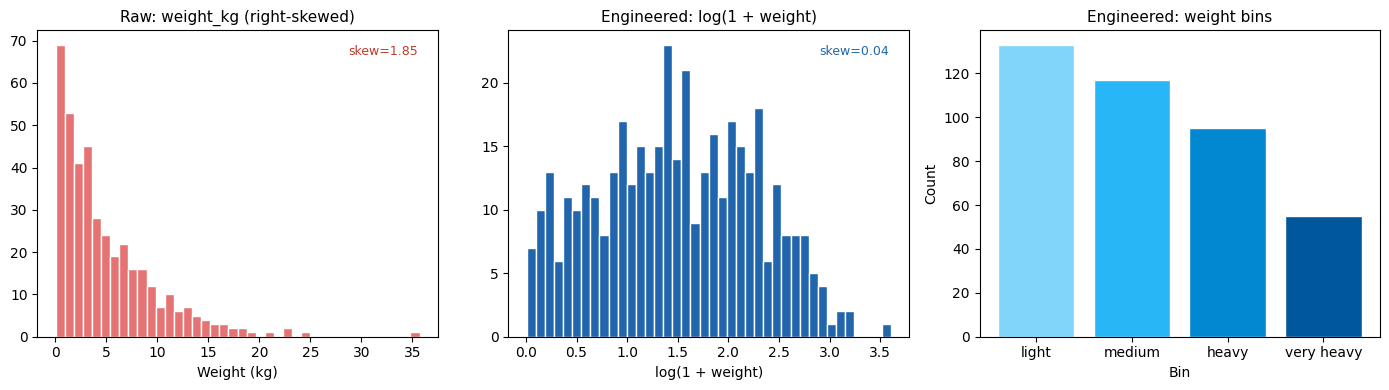

Heavy items (> 7 kg): 102 of 400 (25.5%)


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
df = pd.DataFrame({'weight_kg': np.random.exponential(scale=5, size=400)})

# log transform to reduce skew
df['log_weight'] = np.log1p(df['weight_kg'])

# binary threshold flag
df['is_heavy'] = (df['weight_kg'] > 7).astype(int)

# binning into ordered categories
df['weight_bin'] = pd.cut(
    df['weight_kg'],
    bins=[0, 2, 5, 10, 100],
    labels=['light', 'medium', 'heavy', 'very heavy']
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['weight_kg'], bins=40, color='#e57373', edgecolor='white')
axes[0].set_title('Raw: weight_kg (right-skewed)', fontsize=11)
axes[0].set_xlabel('Weight (kg)')
skew_val = df['weight_kg'].skew()
axes[0].text(0.95, 0.92, f'skew={skew_val:.2f}', transform=axes[0].transAxes,
             ha='right', fontsize=9, color='#c0392b')

axes[1].hist(df['log_weight'], bins=40, color='#2166ac', edgecolor='white')
axes[1].set_title('Engineered: log(1 + weight)', fontsize=11)
axes[1].set_xlabel('log(1 + weight)')
log_skew = df['log_weight'].skew()
axes[1].text(0.95, 0.92, f'skew={log_skew:.2f}', transform=axes[1].transAxes,
             ha='right', fontsize=9, color='#2166ac')

bin_counts = df['weight_bin'].value_counts().reindex(['light', 'medium', 'heavy', 'very heavy'])
axes[2].bar(bin_counts.index, bin_counts.values,
            color=['#81d4fa', '#29b6f6', '#0288d1', '#01579b'], edgecolor='white')
axes[2].set_title('Engineered: weight bins', fontsize=11)
axes[2].set_xlabel('Bin')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Heavy items (> 7 kg): {df['is_heavy'].sum()} of {len(df)} ({df['is_heavy'].mean():.1%})")

### 4d. Unit Conversion and Domain-Threshold Flags

A single raw column can yield multiple informative features by applying **unit conversions**, **integer/remainder splits**, and **domain-knowledge thresholds**.

Article example — `Item_Weight = 6289 grams` produces:

| Engineered feature | Value | Why useful |
|---|---|---|
| `weight_kg` | 6.289 | Standard unit — better scale for regression |
| `weight_kg_floor` | 6 | Integer kg — useful for shipping tier lookup |
| `weight_remainder_g` | 289 | Sub-kg remainder — fine-grained precision |
| `above_4kg` | 1 | Binary domain flag: items ≥ 4 kg attract a higher shipping rate |

The threshold flag encodes **business knowledge** the raw number cannot express on its own.

    item  weight_grams  weight_kg  weight_kg_floor  weight_remainder_g  above_4kg
Widget A          6289      6.289                6                 289          1
Widget B          1450      1.450                1                 450          0
Widget C          9870      9.870                9                 870          1
Widget D          3200      3.200                3                 200          0
Widget E          4050      4.050                4                  50          1
Widget F           750      0.750                0                 750          0



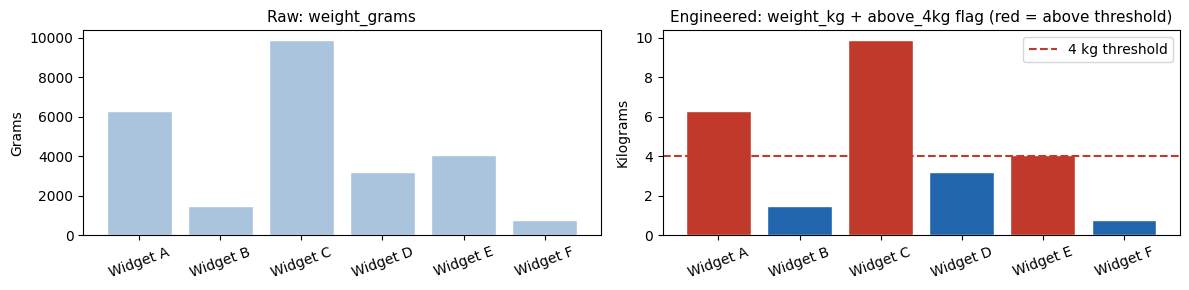

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'item'         : ['Widget A', 'Widget B', 'Widget C', 'Widget D', 'Widget E', 'Widget F'],
    'weight_grams' : [6289,       1450,        9870,       3200,       4050,       750],
})

# unit conversion
df['weight_kg'] = df['weight_grams'] / 1000

# integer / remainder decomposition
df['weight_kg_floor']    = df['weight_kg'].astype(int)
df['weight_remainder_g'] = df['weight_grams'] - df['weight_kg_floor'] * 1000

# domain threshold: items ≥ 4 kg fall into a higher shipping tier
df['above_4kg'] = (df['weight_kg'] >= 4).astype(int)

print(df.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].bar(df['item'], df['weight_grams'], color='#aac4de', edgecolor='white')
axes[0].set_title('Raw: weight_grams', fontsize=11)
axes[0].set_ylabel('Grams')
axes[0].tick_params(axis='x', rotation=20)

colors = ['#c0392b' if v else '#2166ac' for v in df['above_4kg']]
axes[1].bar(df['item'], df['weight_kg'], color=colors, edgecolor='white')
axes[1].axhline(4, color='#c0392b', linestyle='--', linewidth=1.5, label='4 kg threshold')
axes[1].set_title('Engineered: weight_kg + above_4kg flag (red = above threshold)', fontsize=11)
axes[1].set_ylabel('Kilograms')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

### 4e. Decomposing Aggregate Rates into Components

An annual total hides **seasonal patterns**. Splitting it by time period lets the model learn variation the aggregate obscures.

Article example: `Num_Customer_Purchases` (annual) → `Purchases_Summer`, `Purchases_Fall`, `Purchases_Winter`, `Purchases_Spring`

The same pattern applies broadly: any aggregate (monthly revenue, annual visits, total claims) can be decomposed by time, geography, category, or channel.

             total_purchases  purchases_fall  purchases_spring  purchases_summer  purchases_winter  ratio_fall  ratio_spring  ratio_summer  ratio_winter
customer_id                                                                                                                                             
0                          6               2                 2                 2                 0        0.33          0.33          0.33          0.00
1                         18               2                 5                 7                 4        0.11          0.28          0.39          0.22
3                         11               5                 1                 1                 4        0.45          0.09          0.09          0.36
4                         11               2                 5                 3                 1        0.18          0.45          0.27          0.09
5                          3               1                 0                 0  

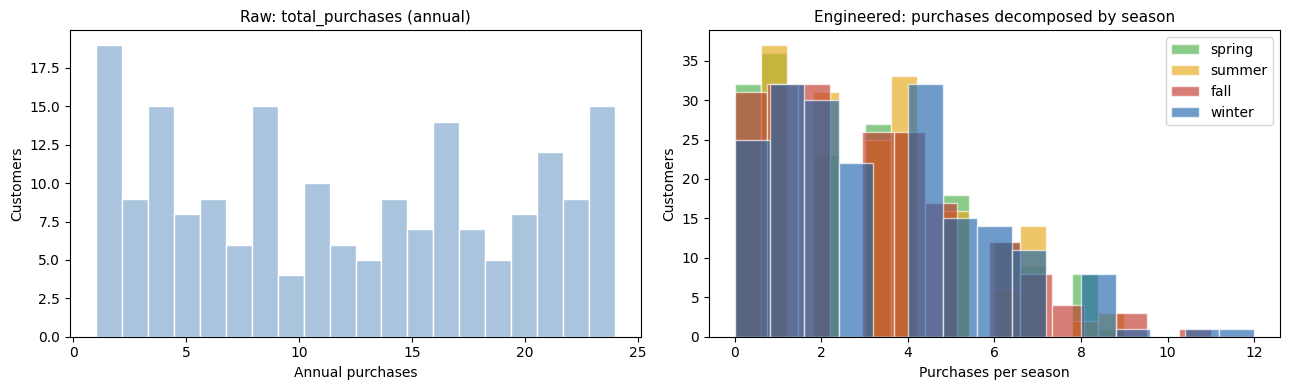

Correlation of seasonal features with total (should be moderate, not 1.0):
total_purchases     1.000000
purchases_spring    0.793761
purchases_summer    0.784548
purchases_fall      0.750914
purchases_winter    0.774583


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# synthetic purchase log: each row is one purchase event
n_customers = 200
records = []
for cid in range(n_customers):
    n_buys = np.random.randint(0, 25)
    months = np.random.choice(range(1, 13), size=n_buys, replace=True)
    for m in months:
        records.append({'customer_id': cid, 'month': m})

purchases = pd.DataFrame(records)

def month_to_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'fall'

purchases['season'] = purchases['month'].apply(month_to_season)

# raw feature: single annual count per customer
annual = purchases.groupby('customer_id').size().rename('total_purchases')

# engineered features: purchases broken down by season
seasonal = (
    purchases.groupby(['customer_id', 'season'])
             .size()
             .unstack(fill_value=0)
             .add_prefix('purchases_')
)

features = annual.to_frame().join(seasonal, how='left').fillna(0).astype(int)

# add seasonal ratio features — fraction of purchases in each season
for col in seasonal.columns:
    ratio_col = col.replace('purchases_', 'ratio_')
    features[ratio_col] = (features[col] / features['total_purchases'].replace(0, 1)).round(2)

print(features.head(8).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(features['total_purchases'], bins=20, color='#aac4de', edgecolor='white')
axes[0].set_title('Raw: total_purchases (annual)', fontsize=11)
axes[0].set_xlabel('Annual purchases')
axes[0].set_ylabel('Customers')

season_cols = ['purchases_spring', 'purchases_summer', 'purchases_fall', 'purchases_winter']
colors      = ['#4daf4a', '#e6a817', '#c0392b', '#2166ac']
for col, color in zip(season_cols, colors):
    axes[1].hist(features[col], bins=15, alpha=0.65, color=color,
                 label=col.replace('purchases_', ''), edgecolor='white')
axes[1].set_title('Engineered: purchases decomposed by season', fontsize=11)
axes[1].set_xlabel('Purchases per season')
axes[1].set_ylabel('Customers')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Correlation of seasonal features with total (should be moderate, not 1.0):")
print(features[['total_purchases'] + season_cols].corr()['total_purchases'].to_string())

### 4f. Domain-Specific Construction: Text (NLP)

In NLP, the raw **observation is a document or sentence**. Feature construction converts it into numeric signals.

Common text features — each requires zero external models:

| Feature | What it captures |
|---|---|
| `word_count` | Document length signal |
| `unique_word_ratio` | Vocabulary diversity — high for literary text, low for spam |
| `avg_word_length` | Writing style — longer words often signal formal/technical text |
| `exclamation_count` | Urgency / spam signal |
| `keyword_flag` | Domain-specific presence of a known important term |

label                                                          text  word_count  unique_word_ratio  avg_word_len  exclamation_count  has_ml_keyword
  ham                   The quick brown fox jumps over the lazy dog           9           0.888889      3.888889                  0               0
  ham       Machine learning is a subset of artificial intelligence           8           1.000000      6.000000                  0               1
  ham  Feature engineering transforms raw data into useful features           8           1.000000      6.625000                  0               1
 spam       Buy now! Limited offer! Click here for amazing deals!!!           9           1.000000      4.666667                  5               0
 spam               Win big! Free prize! Act now! Don't miss out!!!           9           1.000000      3.666667                  6               0
  ham                     Short informative text about data science           6           1.000000      6.000000

/tmp/ipykernel_674875/519904532.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_ml_keyword']    = df['text'].str.contains(


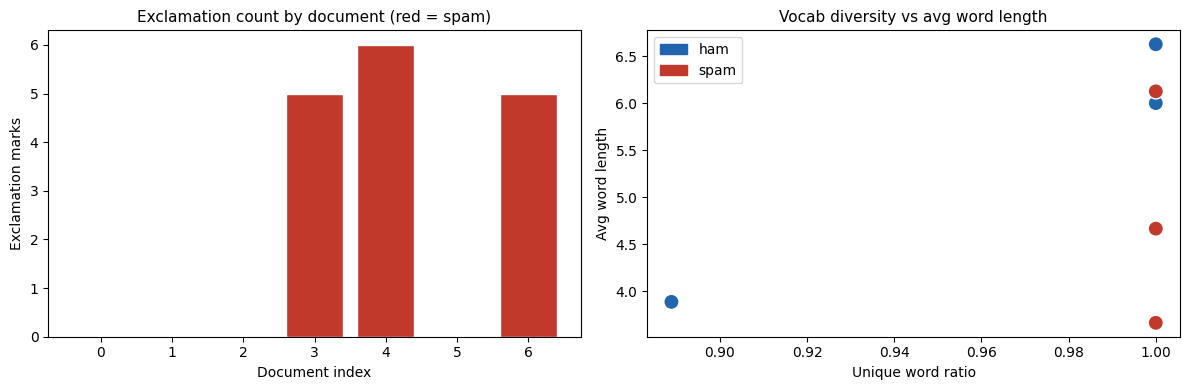

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

docs = [
    ("ham",  "The quick brown fox jumps over the lazy dog"),
    ("ham",  "Machine learning is a subset of artificial intelligence"),
    ("ham",  "Feature engineering transforms raw data into useful features"),
    ("spam", "Buy now! Limited offer! Click here for amazing deals!!!"),
    ("spam", "Win big! Free prize! Act now! Don't miss out!!!"),
    ("ham",  "Short informative text about data science"),
    ("spam", "Congratulations! You have been selected! Claim your reward!!!"),
]

df = pd.DataFrame(docs, columns=['label', 'text'])

# word count
df['word_count']        = df['text'].apply(lambda t: len(t.split()))

# unique word ratio — vocabulary diversity
df['unique_word_ratio'] = df['text'].apply(
    lambda t: len(set(t.lower().split())) / len(t.split())
)

# average word length — proxy for formality
df['avg_word_len']      = df['text'].apply(
    lambda t: sum(len(w.strip('!.,')) for w in t.split()) / len(t.split())
)

# punctuation signal
df['exclamation_count'] = df['text'].str.count(r'!')

# domain keyword flag
df['has_ml_keyword']    = df['text'].str.contains(
    r'\b(learning|data|feature|intelligence)\b', case=False
).astype(int)

feature_cols = ['word_count', 'unique_word_ratio', 'avg_word_len',
                'exclamation_count', 'has_ml_keyword']

print(df[['label', 'text'] + feature_cols].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2166ac' if l == 'ham' else '#c0392b' for l in df['label']]

axes[0].bar(range(len(df)), df['exclamation_count'], color=colors, edgecolor='white')
axes[0].set_title('Exclamation count by document (red = spam)', fontsize=11)
axes[0].set_xlabel('Document index')
axes[0].set_ylabel('Exclamation marks')

axes[1].scatter(df['unique_word_ratio'], df['avg_word_len'],
                c=colors, s=120, edgecolors='white', linewidths=1)
axes[1].set_title('Vocab diversity vs avg word length', fontsize=11)
axes[1].set_xlabel('Unique word ratio')
axes[1].set_ylabel('Avg word length')

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2166ac', label='ham'),
                         Patch(color='#c0392b', label='spam')])

plt.tight_layout()
plt.show()

### 4g. Aggregation: Counts, Mins, Maxes

When observations belong to a group (customer, patient, product), you can **aggregate** per-row features into group-level summary statistics. The article's Heritage Health Prize example:

| Raw feature | Aggregated features |
|---|---|
| individual claim amount | count of claims, min amount, max amount, range |
| claim date | first claim, last claim, span in days |
| diagnosis code | count of unique codes |

Aggregation features are powerful because they capture **behavioural history** that a single row cannot express. They are a staple of tabular Kaggle competitions.

Raw claims (first 8 rows):
 patient_id  claim_amount  claim_day diagnosis_code
          0     11.967754         87           D005
          0    183.816431        151           D003
          0      4.159862        257           D004
          0    557.915106        191           D004
          0     40.522285        313           D005
          0    113.107413         48           D003
          1    307.587202         50           D004
          1    144.405831        319           D001

Aggregated patient features (first 8 rows):
 patient_id  claim_count  total_claim  min_claim  max_claim  mean_claim  claim_range  first_claim_day  last_claim_day  claim_span_days  unique_diag_codes
          0            6   911.488850   4.159862 557.915106  151.914808   553.755244               48             313              265                  3
          1            5  1151.414208   9.512770 570.159376  230.282842   560.646606               13             319              306                  

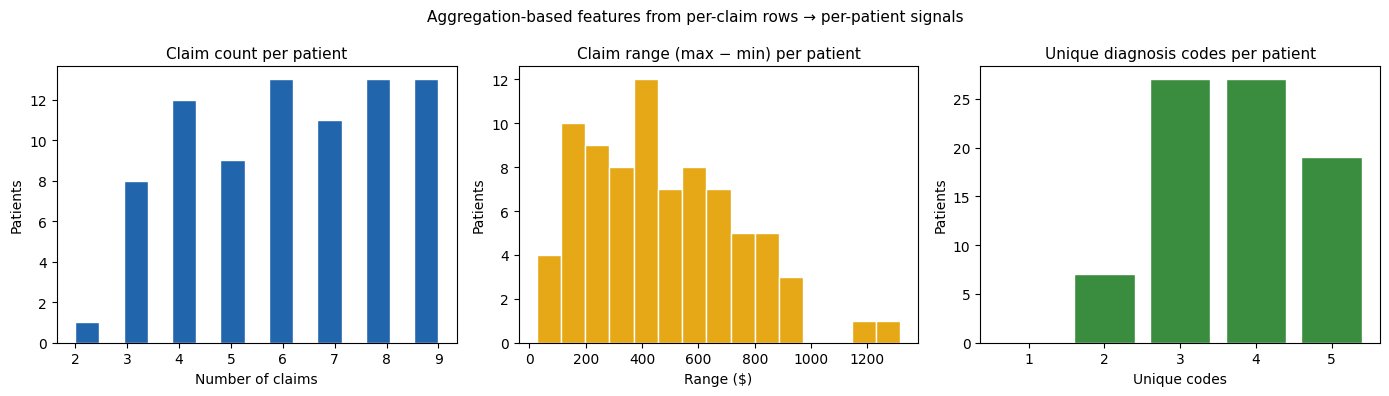

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# simulate individual medical claims per patient
n_patients = 80
claims = []
for pid in range(n_patients):
    n_claims = np.random.poisson(lam=5) + 1
    for _ in range(n_claims):
        claims.append({
            'patient_id'    : pid,
            'claim_amount'  : np.random.exponential(scale=200),
            'claim_day'     : np.random.randint(0, 365),
            'diagnosis_code': np.random.choice(['D001', 'D002', 'D003', 'D004', 'D005'])
        })

df_claims = pd.DataFrame(claims)

# aggregation-based feature construction
agg = df_claims.groupby('patient_id').agg(
    claim_count       = ('claim_amount',   'count'),
    total_claim       = ('claim_amount',   'sum'),
    min_claim         = ('claim_amount',   'min'),
    max_claim         = ('claim_amount',   'max'),
    mean_claim        = ('claim_amount',   'mean'),
    claim_range       = ('claim_amount',   lambda x: x.max() - x.min()),
    first_claim_day   = ('claim_day',      'min'),
    last_claim_day    = ('claim_day',      'max'),
    claim_span_days   = ('claim_day',      lambda x: x.max() - x.min()),
    unique_diag_codes = ('diagnosis_code', 'nunique')
).reset_index()

print("Raw claims (first 8 rows):")
print(df_claims.head(8).to_string(index=False))
print()
print("Aggregated patient features (first 8 rows):")
print(agg.head(8).to_string(index=False))
print()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(agg['claim_count'], bins=15, color='#2166ac', edgecolor='white')
axes[0].set_title('Claim count per patient', fontsize=11)
axes[0].set_xlabel('Number of claims')
axes[0].set_ylabel('Patients')

axes[1].hist(agg['claim_range'], bins=15, color='#e6a817', edgecolor='white')
axes[1].set_title('Claim range (max − min) per patient', fontsize=11)
axes[1].set_xlabel('Range ($)')
axes[1].set_ylabel('Patients')

# reindex to ensure all values 1–5 are present even if some don't appear
code_counts = agg['unique_diag_codes'].value_counts().reindex(range(1, 6), fill_value=0).sort_index()
axes[2].bar(range(1, 6), code_counts, color='#3a8c3f', edgecolor='white')
axes[2].set_title('Unique diagnosis codes per patient', fontsize=11)
axes[2].set_xlabel('Unique codes')
axes[2].set_ylabel('Patients')

plt.suptitle('Aggregation-based features from per-claim rows → per-patient signals', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Feature Learning

Instead of manually specifying features, **feature learning** lets a model discover its own representations from raw data automatically.

### All Methods at a Glance

| Method | How it works | When to use |
|---|---|---|
| **Autoencoder** | Encoder-bottleneck-decoder neural net; minimize reconstruction error | General-purpose; non-linear; works on images, tabular, sequences |
| **Restricted Boltzmann Machine (RBM)** | Two-layer generative model (visible + hidden); learns probabilistic representations | Collaborative filtering; pre-training deep nets; `BernoulliRBM` in sklearn |
| **CNN features** | Convolutional layers learn spatial hierarchies | Images and 2D spatial data — the dominant method; use a pre-trained backbone (ResNet, EfficientNet) |
| **Word2Vec / FastText** | Predict context words; learn word co-occurrence vectors | Text with vocabulary relationships; fast to train; good for domain-specific corpora |
| **BERT / Transformer embeddings** | Attention-based contextual representations | State-of-the-art NLP; use pre-trained models via HuggingFace; needs GPU for fine-tuning |
| **Variational Autoencoder (VAE)** | Autoencoder with probabilistic bottleneck (latent distribution) | Generative tasks; interpolation; disentangled representations |
| **GAN discriminator features** | Features from the discriminator of a trained GAN | Image quality assessment; semi-supervised; rarely used for direct feature extraction |

### Rule of Thumb
- For **images**: use CNN features from a pre-trained model (transfer learning) — don't train from scratch unless you have millions of images  
- For **text**: use BERT-family embeddings for quality, Word2Vec for speed  
- For **tabular data**: manual construction almost always beats learned features — autoencoders rarely help unless the table is very wide (100+ features) or has heavy missingness  
- RBMs are largely superseded by autoencoders but remain useful for recommendation systems  

### Limitations

| Limitation | Why it matters |
|---|---|
| **Black-box representations** | Learned features are not interpretable — you cannot name or reason about them |
| **Non-transferable insight** | Features learned on one dataset rarely transfer; domain knowledge does |
| **Requires large data** | Autoencoders and RBMs overfit badly on small datasets |
| **Cannot be manually guided** | You cannot inject domain knowledge ("this threshold matters") |

> Rule of thumb: prefer feature learning for **large, high-dimensional raw data** (images, audio, text). For structured tabular data, manual construction usually wins.

An **autoencoder** (64 → 16 → 64) on digit images is shown below.

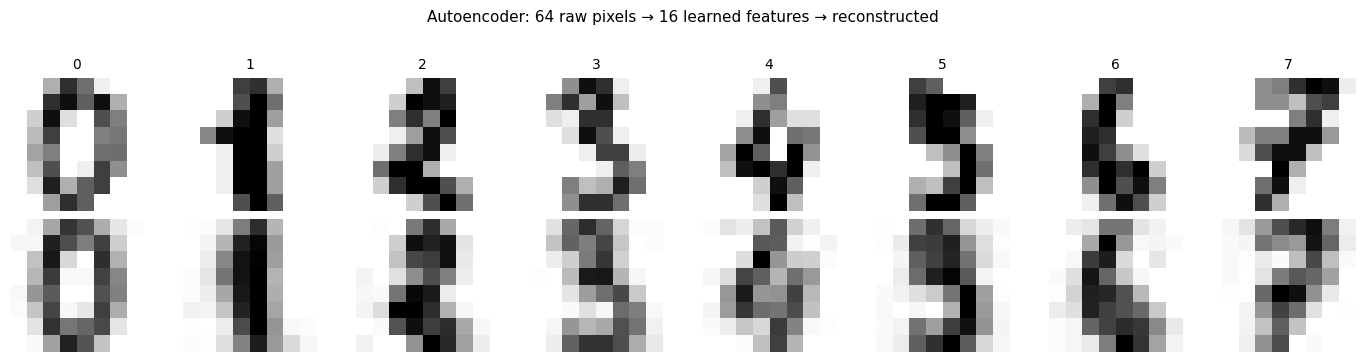

Original dimensions : 64
Bottleneck (learned): 16
Reconstruction MSE  : 0.0192


In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import load_digits

digits   = load_digits()
X_digits = MinMaxScaler().fit_transform(digits.data)

# autoencoder: 64 → 32 → 16 (bottleneck) → 32 → 64
autoencoder = MLPRegressor(
    hidden_layer_sizes=(32, 16, 32),
    activation='relu',
    max_iter=300,
    random_state=42,
    verbose=False
)
autoencoder.fit(X_digits, X_digits)
reconstructed = autoencoder.predict(X_digits[:8])

fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for i in range(8):
    axes[0, i].imshow(X_digits[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(str(digits.target[i]), fontsize=10)

    axes[1, i].imshow(reconstructed[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original\n(64 px)', fontsize=9)
axes[1, 0].set_ylabel('Learned\n(16-dim)', fontsize=9)
plt.suptitle('Autoencoder: 64 raw pixels → 16 learned features → reconstructed',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

mse = np.mean((X_digits[:8] - reconstructed) ** 2)
print(f"Original dimensions : 64")
print(f"Bottleneck (learned): 16")
print(f"Reconstruction MSE  : {mse:.4f}")

## Putting It All Together: A Complete Pipeline

A realistic feature engineering pipeline combines construction, selection, and extraction in sequence.

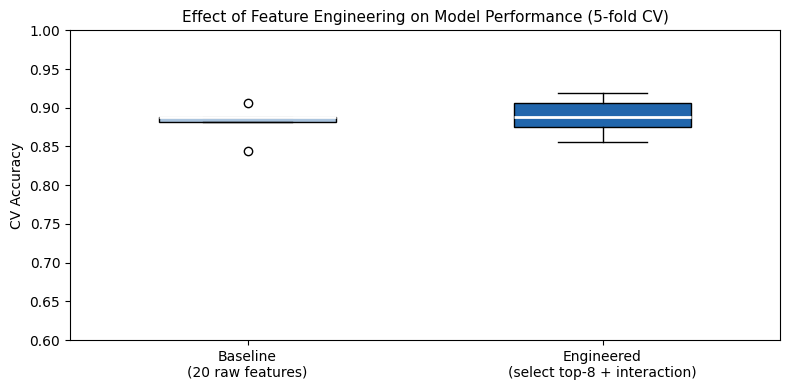

Baseline   : 0.881 ± 0.021
Engineered : 0.889 ± 0.022


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification

np.random.seed(42)
X_raw, y = make_classification(
    n_samples=800, n_features=20, n_informative=6,
    n_redundant=6, n_clusters_per_class=2, random_state=42
)

# construct a simple interaction feature (product of first two)
interaction = (X_raw[:, 0] * X_raw[:, 1]).reshape(-1, 1)
X_engineered = np.hstack([X_raw, interaction])

# pipelines: baseline vs with feature selection
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])

engineered_pipe = Pipeline([
    ('scaler',    StandardScaler()),
    ('selection', SelectKBest(f_classif, k=8)),
    ('model',     RandomForestClassifier(n_estimators=100, random_state=42))
])

# cross-validation scores
baseline_scores  = cross_val_score(baseline_pipe,   X_raw,        y, cv=5)
engineered_scores= cross_val_score(engineered_pipe, X_engineered, y, cv=5)

fig, ax = plt.subplots(figsize=(8, 4))
positions = [1, 2]
bp = ax.boxplot([baseline_scores, engineered_scores],
                positions=positions, widths=0.5, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor('#aac4de')
bp['boxes'][1].set_facecolor('#2166ac')
ax.set_xticks(positions)
ax.set_xticklabels(['Baseline\n(20 raw features)', 'Engineered\n(select top-8 + interaction)'])
ax.set_ylabel('CV Accuracy')
ax.set_title('Effect of Feature Engineering on Model Performance (5-fold CV)', fontsize=11)
ax.set_ylim(0.6, 1.0)
plt.tight_layout()
plt.show()

print(f"Baseline   : {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}")
print(f"Engineered : {engineered_scores.mean():.3f} ± {engineered_scores.std():.3f}")

## Real-World Case Studies

### KDD Cup 2010 — Student Performance Prediction
The winning team's strategy was almost entirely feature engineering:  
- Decomposed **temporal sequences** of student actions into millions of binary features  
- A simple logistic regression on engineered features outperformed complex models on raw data  
> *"Feature Engineering and Classifier Ensemble for KDD Cup 2010"* — NTU team

### Heritage Health Prize — Hospital Re-admission Prediction
Milestone prize winners built features by:
- Creating **counts** (number of claims per patient)
- Computing **mins, maxes, and ranges** of numerical attributes
- **Discretizing** continuous values into categorical buckets  
> *"Round 1 Milestone Prize: How We Did It – Team Market Makers"*

Both competitions illustrate the same lesson: **better features beat better algorithms**.

## How to Get Good at Feature Engineering

Feature engineering is part science, part craft — it improves with deliberate practice.

<figure style="margin:16px 0">
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 740 175" width="740" height="175"
     font-family="Segoe UI, Arial, sans-serif">
  <defs>
    <marker id="fw_how" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto">
      <path d="M0,0 L0,6 L9,3 z" fill="#555"/>
    </marker>
    <marker id="fb_how" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto">
      <path d="M0,0 L0,6 L9,3 z" fill="#c0392b"/>
    </marker>
  </defs>
  <rect width="740" height="175" fill="#f9f9fb" rx="8"/>
  <text x="370" y="22" text-anchor="middle" font-size="12" font-weight="bold" fill="#1a1a2e">Feature Engineering Iteration Cycle</text>

  <rect x="10"  y="36" width="155" height="56" rx="7" fill="#dce9f7" stroke="#2166ac" stroke-width="1.5"/>
  <text x="87"  y="61" text-anchor="middle" font-size="12" font-weight="bold" fill="#2166ac">Brainstorm</text>
  <text x="87"  y="78" text-anchor="middle" font-size="9"  fill="#333">List all possible features</text>

  <rect x="185" y="36" width="155" height="56" rx="7" fill="#e8f5e9" stroke="#3a8c3f" stroke-width="1.5"/>
  <text x="262" y="61" text-anchor="middle" font-size="12" font-weight="bold" fill="#2e7d32">Devise</text>
  <text x="262" y="78" text-anchor="middle" font-size="9"  fill="#333">Implement promising ideas</text>

  <rect x="360" y="36" width="155" height="56" rx="7" fill="#fff3cd" stroke="#e6a817" stroke-width="1.5"/>
  <text x="437" y="61" text-anchor="middle" font-size="12" font-weight="bold" fill="#856404">Select</text>
  <text x="437" y="78" text-anchor="middle" font-size="9"  fill="#333">Prune with importance scores</text>

  <rect x="535" y="36" width="195" height="56" rx="7" fill="#fde8e8" stroke="#c0392b" stroke-width="1.5"/>
  <text x="632" y="61" text-anchor="middle" font-size="12" font-weight="bold" fill="#c0392b">Evaluate Model</text>
  <text x="632" y="78" text-anchor="middle" font-size="9"  fill="#333">Train, measure, decide</text>

  <line x1="165" y1="64" x2="183" y2="64" stroke="#555" stroke-width="1.8" marker-end="url(#fw_how)"/>
  <line x1="340" y1="64" x2="358" y2="64" stroke="#555" stroke-width="1.8" marker-end="url(#fw_how)"/>
  <line x1="515" y1="64" x2="533" y2="64" stroke="#555" stroke-width="1.8" marker-end="url(#fw_how)"/>

  <path d="M730,92 Q730,152 370,152 Q10,152 10,92"
        fill="none" stroke="#c0392b" stroke-width="1.6" stroke-dasharray="6,3"
        marker-end="url(#fb_how)"/>
  <text x="370" y="167" text-anchor="middle" font-size="10" fill="#c0392b">iterate — evaluation drives new feature ideas</text>
</svg>
</figure>

| Stage | What to do |
|---|---|
| **Brainstorm** | List every feature you could imagine — domain knowledge, gut feel, prior work |
| **Devise** | Implement the most promising ideas; keep it cheap (manual transforms first) |
| **Select** | Use importance scores or selection methods to prune noise |
| **Evaluate** | Train a model and measure; let the metric tell you which features matter |

### Stopping Criteria

You cannot engineer features forever — know when to stop:

- Stop when **model accuracy plateaus** across several iterations with no meaningful gain
- Stop when the **feature count grows but test performance stops tracking** — a sign of overfitting to training noise
- Stop when you **run out of domain hypotheses** — at that point you are guessing, not reasoning
- Stop when the **deadline arrives** — a working model with good-enough features beats a perfect model that ships late

### Test Harness Design

The evaluation loop is only useful if your test harness is **stable and objective**:

- Use a **fixed train/test split or fixed CV folds** — reshuffling between iterations means metric changes could reflect data split luck, not feature quality
- **Choose your metric once and stick to it** — switching from accuracy to AUC mid-experiment invalidates comparisons
- Keep a **baseline score** on record — every feature set should be compared to it, not just to the previous iteration
- Never let **test-set labels inform feature construction** — that is leakage; validation must be strictly held out

> The test harness is not just infrastructure — it is your measuring instrument. A noisy instrument cannot tell you whether a new feature helps.

**Practical tips:**
- Study Kaggle competition writeups — feature engineering is almost always the deciding factor
- Read domain literature to understand what transformations make physical / business sense
- Prefer more features early, then prune — it is easier to remove than to invent
- The data changes with every problem; treat each dataset as a new apprenticeship

## References

### Primary Source
- [Discover Feature Engineering, How to Engineer Features and How to Get Good at It — Machine Learning Mastery](https://machinelearningmastery.com/discover-feature-engineering-how-to-engineer-features-and-how-to-get-good-at-it/)

### Key Articles & Papers
- [Neglected Machine Learning Ideas — Scott Locklin](https://scottlocklin.wordpress.com/2014/07/22/neglected-machine-learning-ideas/)
- [Q&A with Xavier Conort — Kaggle Blog](https://blog.kaggle.com/2013/04/10/qa-with-xavier-conort/)
- [A Few Useful Things to Know about Machine Learning — Pedro Domingos (PDF)](http://homes.cs.washington.edu/~pedrod/papers/cacm12.pdf)
- [Feature Engineering and Classifier Ensemble for KDD Cup 2010 (PDF)](https://pslcdatashop.web.cmu.edu/KDDCup/workshop/papers/kdd2010ntu.pdf)
- [Round 1 Milestone Prize: How We Did It — Team Market Makers (PDF)](https://foreverdata.org/1015/content/milestone1-2.pdf)
- [JMLR Special Issue on Variable and Feature Selection](http://jmlr.org/papers/special/feature03.html)

### Wikipedia
- [Feature (machine learning)](https://en.wikipedia.org/wiki/Feature_(machine_learning))
- [Feature extraction](https://en.wikipedia.org/wiki/Feature_extraction)
- [Feature selection](https://en.wikipedia.org/wiki/Feature_selection)
- [Feature learning](https://en.wikipedia.org/wiki/Feature_learning)
- [Feature engineering](https://en.wikipedia.org/wiki/Feature_engineering)
- [Random Forest variable importance](https://en.wikipedia.org/wiki/Random_forest#Variable_importance)

### Lecture Notes & Slides
- [Feature Engineering — Knowledge Technologies Institute, TU Graz (PDF)](http://kti.tugraz.at/staff/denis/courses/kddm1/featureengineering.pdf)
- [Feature Engineering and Selection — Berkeley, Jordan (PDF)](http://www.cs.berkeley.edu/~jordan/courses/294-fall09/lectures/feature/slides.pdf)
- [Feature Engineering — Princeton COS424 (PDF)](http://www.cs.princeton.edu/courses/archive/spring10/cos424/slides/18-feat.pdf)
- [Feature Engineering Studio — Columbia](http://www.columbia.edu/~rsb2162/FES2013/materials.html)

### Books
- [Feature Extraction, Construction and Selection: A Data Mining Perspective](https://amzn.to/3hcglhH)
- [Feature Extraction: Foundations and Applications](https://amzn.to/2Y0RJka)
- [Feature Extraction & Image Processing for Computer Vision](https://amzn.to/3iLaCjg)
- [Feature Selection for Knowledge Discovery and Data Mining](https://amzn.to/31UeSWD)
- [Computational Methods of Feature Selection](https://amzn.to/33ZZsCP)

### Tutorials & Notebooks
- [Feature Engineering on the Titanic — Trevor Stephens](http://trevorstephens.com/post/73461351896/titanic-getting-started-with-r-part-4-feature)
- [Feature Engineering IPython Notebook — Guibing Guo](http://nbviewer.ipython.org/url/trust.sce.ntu.edu.sg/~gguo1/blogs/Features.ipynb)
- [Feature Engineering Video — YouTube](https://www.youtube.com/watch?v=drUToKxEAUA)

### Related Machine Learning Mastery Articles
- [An Introduction to Feature Selection](https://machinelearningmastery.com/an-introduction-to-feature-selection/)
- [Data Preparation for Machine Learning](https://machinelearningmastery.com/data-preparation-for-machine-learning/)
- [A Gentle Introduction to Predictive Modeling](https://machinelearningmastery.com/gentle-introduction-to-predictive-modeling/)
- [Process for Working Through Machine Learning Problems](https://machinelearningmastery.com/process-for-working-through-machine-learning-problems/)
- [What is Data Mining and KDD](https://machinelearningmastery.com/what-is-data-mining-and-kdd/)
- [Discover the Methodology and Mindset of a Kaggle Master](https://machinelearningmastery.com/discover-the-methodology-and-mindset-of-a-kaggle-master-an-interview-with-diogo-ferreira/)

In [ ]:
import urllib.request
import pathlib
import ssl
import time

refs_dir = pathlib.Path('references')
refs_dir.mkdir(exist_ok=True)

# each entry: (filename, [primary_url, fallback_url, ...], title)
pdfs = [
    (
        'domingos_few_useful_things.pdf',
        [
            'http://homes.cs.washington.edu/~pedrod/papers/cacm12.pdf',
            'https://web.archive.org/web/2023/http://homes.cs.washington.edu/~pedrod/papers/cacm12.pdf',
        ],
        'A Few Useful Things — Domingos'
    ),
    (
        'kdd2010_ntu_feature_engineering.pdf',
        [
            'https://pslcdatashop.web.cmu.edu/KDDCup/workshop/papers/kdd2010ntu.pdf',
            'https://web.archive.org/web/2023/https://pslcdatashop.web.cmu.edu/KDDCup/workshop/papers/kdd2010ntu.pdf',
        ],
        'KDD Cup 2010 — NTU Feature Engineering'
    ),
    (
        'heritage_health_milestone1.pdf',
        [
            'https://foreverdata.org/1015/content/milestone1-2.pdf',
            'https://web.archive.org/web/2023/https://foreverdata.org/1015/content/milestone1-2.pdf',
        ],
        'Heritage Health Prize — Team Market Makers'
    ),
    (
        'tugraz_feature_engineering.pdf',
        [
            'http://kti.tugraz.at/staff/denis/courses/kddm1/featureengineering.pdf',
            'https://web.archive.org/web/2023/http://kti.tugraz.at/staff/denis/courses/kddm1/featureengineering.pdf',
        ],
        'Feature Engineering — TU Graz'
    ),
    (
        'berkeley_jordan_feature_selection.pdf',
        [
            'http://www.cs.berkeley.edu/~jordan/courses/294-fall09/lectures/feature/slides.pdf',
            'https://web.archive.org/web/2023/http://www.cs.berkeley.edu/~jordan/courses/294-fall09/lectures/feature/slides.pdf',
        ],
        'Feature Engineering & Selection — Berkeley Jordan'
    ),
    (
        'princeton_cos424_features.pdf',
        [
            'http://www.cs.princeton.edu/courses/archive/spring10/cos424/slides/18-feat.pdf',
            'https://web.archive.org/web/2023/http://www.cs.princeton.edu/courses/archive/spring10/cos424/slides/18-feat.pdf',
        ],
        'Feature Engineering — Princeton COS424'
    ),
]

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

headers = {'User-Agent': 'Mozilla/5.0 (compatible; notebook-downloader/1.0)'}

for filename, urls, title in pdfs:
    dest = refs_dir / filename
    if dest.exists():
        print(f'  skip  {filename}  (already downloaded)')
        continue
    for url in urls:
        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req, timeout=30, context=ctx) as resp:
                dest.write_bytes(resp.read())
            size_kb = dest.stat().st_size // 1024
            source = 'wayback' if 'archive.org' in url else 'primary'
            print(f'  ok    {filename}  ({size_kb} KB)  [{source}]  — {title}')
            break
        except Exception as e:
            print(f'  fail  {url}  — {e}')
    else:
        print(f'  FAIL  {filename}  — all urls failed')
    time.sleep(0.5)

print(f'\nDownloaded to: {refs_dir.resolve()}')